In [65]:
import numpy as np
import pandas as pd

In [66]:
from google.colab import files
data = files.upload()

Saving KNN_Project_Data to KNN_Project_Data (1)


In [67]:
df=pd.read_csv("KNN_Project_Data")
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   XVPM          1000 non-null   float64
 1   GWYH          1000 non-null   float64
 2   TRAT          1000 non-null   float64
 3   TLLZ          1000 non-null   float64
 4   IGGA          1000 non-null   float64
 5   HYKR          1000 non-null   float64
 6   EDFS          1000 non-null   float64
 7   GUUB          1000 non-null   float64
 8   MGJM          1000 non-null   float64
 9   JHZC          1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [69]:
df['TARGET CLASS'].unique()

array([0, 1])

In [70]:
df.corr()*100

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
XVPM,100.000000,-0.481577,-1.421908,5.525600,0.368753,0.188272,-2.352560,3.211800,-1.609135,2.622233,-7.989598
GWYH,-0.481577,100.000000,-22.485857,12.162259,-10.479516,4.252939,-10.222094,6.155298,3.972766,10.553224,-41.616781
TRAT,-1.421908,-22.485857,100.000000,-3.772613,12.487000,0.546176,11.873592,-7.320266,-6.717713,-11.981587,48.934724
TLLZ,5.525600,12.162259,-3.772613,100.000000,-0.554463,-0.479167,-6.398907,5.395838,9.412060,6.514253,-17.202922
IGGA,0.368753,-10.479516,12.487000,-0.554463,100.000000,0.363056,7.630380,-4.213395,-1.168808,-6.689525,29.539039
HYKR,0.188272,4.252939,0.546176,-0.479167,0.363056,100.000000,-0.745232,0.489067,2.555333,-0.640261,-1.526606
EDFS,-2.352560,-10.222094,11.873592,-6.398907,7.630380,-0.745232,100.000000,-7.136077,0.586474,-4.792824,28.160746
GUUB,3.211800,6.155298,-7.320266,5.395838,-4.213395,0.489067,-7.136077,100.000000,1.150678,6.116970,-17.449566
MGJM,-1.609135,3.972766,-6.717713,9.412060,-1.168808,2.555333,0.586474,1.150678,100.000000,1.434236,-9.888667
JHZC,2.622233,10.553224,-11.981587,6.514253,-6.689525,-0.640261,-4.792824,6.116970,1.434236,100.000000,-30.172485


In [71]:
x=df.drop('TARGET CLASS',axis=1)
y = df['TARGET CLASS']

In [72]:
x.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792


In [83]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42,shuffle=False)

In [84]:
x_train.shape

(800, 10)

In [85]:
x_test.shape

(200, 10)

In [86]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

In [87]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [88]:
y_pred = knn.predict(x_test)

In [89]:
y_pred[0:5]

array([1, 0, 0, 1, 0])

In [90]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy= accuracy_score(y_test,y_pred)*100
print(f"accuracy:{accuracy}")

confusion_matrix=confusion_matrix(y_test,y_pred)
print(f"confusion_matrix:{confusion_matrix}")





accuracy:77.5
confusion_matrix:[[72 24]
 [21 83]]


In [95]:
accuracy =[]
for i in range(1,21):
  knn =KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  y_pred = knn.predict(x_test)
  score =accuracy_score(y_test,y_pred)*100
  accuracy.append(score)
accuracy

[75.0,
 72.0,
 75.0,
 76.0,
 77.5,
 77.0,
 77.5,
 78.5,
 79.5,
 79.5,
 80.0,
 81.5,
 80.5,
 80.0,
 79.5,
 79.0,
 79.0,
 80.0,
 80.0,
 78.5]

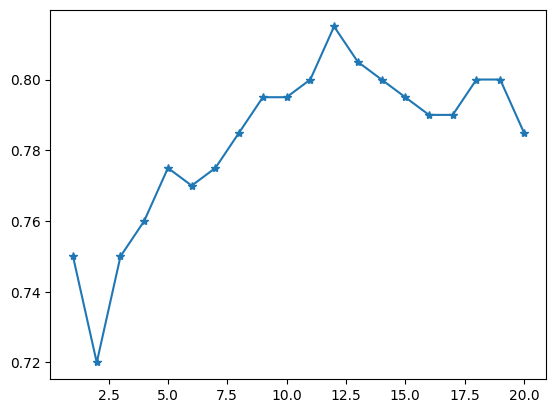

In [92]:
import matplotlib.pyplot as plt
plt.plot(range(1,21),accuracy,'-*')